In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv("smart_preprocessing_test.csv")

In [4]:
def dataset_profile(df):
    profile = {}

    profile["shape"] = df.shape
    profile["missing_values"] = df.isnull().sum()
    profile["duplicates"] = df.duplicated().sum()

    numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
    categorical_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

    profile["numerical_columns"] = numerical_cols
    profile["categorical_columns"] = categorical_cols

    return profile

In [5]:
profile = dataset_profile(df)

print("Shape:", profile["shape"])
print("\nDuplicates:", profile["duplicates"])
print("\nMissing Values:")
print(profile["missing_values"])

print("\nNumerical Columns:")
print(profile["numerical_columns"])

print("\nCategorical Columns:")
print(profile["categorical_columns"])

Shape: (901, 15)

Duplicates: 119

Missing Values:
survived         0
pclass           0
sex              0
age            215
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           697
embark_town      2
alive            0
alone            0
dtype: int64

Numerical Columns:
['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']

Categorical Columns:
['sex', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']


In [6]:
def recommend_missing_values(df):

    recommendations = {}

    for col in df.columns:

        missing_count = df[col].isnull().sum()

        if missing_count == 0:
            continue

        missing_percent = (missing_count / len(df)) * 100
        dtype = df[col].dtype

        # More than 50% missing values
        if missing_percent > 50:

            recommendations[col] = {
                "Recommendation": "Drop Column",
                "Alternatives": [
                    "Arbitrary Value Imputation"
                ],
                "Reason": (
                    f"{missing_percent:.2f}% values are missing. "
                    "Too much information is unavailable."
                )
            }

        # Numerical columns
        elif dtype in ["int64", "float64"]:

            skew = abs(df[col].dropna().skew())

            if skew < 0.5:
                recommendation = "Mean Imputation"

                reason = (
                    f"Skewness = {skew:.2f}. "
                    "Data is approximately normal."
                )

            else:
                recommendation = "Median Imputation"

                reason = (
                    f"Skewness = {skew:.2f}. "
                    "Data is skewed."
                )

            recommendations[col] = {
                "Recommendation": recommendation,
                "Alternatives": [
                    "Mean Imputation",
                    "Median Imputation",
                    "KNN Imputation",
                    "CCA",
                    "Arbitrary Value Imputation"
                ],
                "Reason": reason
            }

        # Categorical columns
        else:

            recommendations[col] = {
                "Recommendation": "Mode Imputation",
                "Alternatives": [
                    "CCA",
                    "Arbitrary Category Imputation"
                ],
                "Reason": (
                    "Categorical feature with few missing values. "
                    "Mode preserves the most frequent category."
                )
            }

    return recommendations

In [7]:
recommendations = recommend_missing_values(df)

for col, rec in recommendations.items():

    print("\n" + "=" * 50)

    print("Column:", col)

    print("Recommendation:",
          rec["Recommendation"])

    print("\nAlternatives:")

    for method in rec["Alternatives"]:
        print("-", method)

    print("\nReason:")
    print(rec["Reason"])


Column: age
Recommendation: Mean Imputation

Alternatives:
- Mean Imputation
- Median Imputation
- KNN Imputation
- CCA
- Arbitrary Value Imputation

Reason:
Skewness = 0.36. Data is approximately normal.

Column: embarked
Recommendation: Mode Imputation

Alternatives:
- CCA
- Arbitrary Category Imputation

Reason:
Categorical feature with few missing values. Mode preserves the most frequent category.

Column: deck
Recommendation: Drop Column

Alternatives:
- Arbitrary Value Imputation

Reason:
77.36% values are missing. Too much information is unavailable.

Column: embark_town
Recommendation: Mode Imputation

Alternatives:
- CCA
- Arbitrary Category Imputation

Reason:
Categorical feature with few missing values. Mode preserves the most frequent category.


In [8]:
def mean_imputation(df, col):
    df[col] = df[col].fillna(df[col].mean())
    return df

def median_imputation(df, col):
    df[col] = df[col].fillna(df[col].median())
    return df

def mode_imputation(df, col):
    df[col] = df[col].fillna(df[col].mode()[0])
    return df

def cca(df, col):
    return df.dropna(subset=[col])

def arbitrary_value(df, col, value=-999):
    df[col] = df[col].fillna(value)
    return df

def arbitrary_category(df, col):
    df[col] = df[col].fillna("Missing")
    return df

In [9]:
from sklearn.impute import KNNImputer

def knn_imputation(df, cols, n_neighbors=5):
    imputer = KNNImputer(n_neighbors=n_neighbors)

    df[cols] = imputer.fit_transform(df[cols])

    return df

In [10]:
def apply_imputation(df, col, method):

    if method == "Mean Imputation":
        return mean_imputation(df, col)

    elif method == "Median Imputation":
        return median_imputation(df, col)

    elif method == "Mode Imputation":
        return mode_imputation(df, col)

    elif method == "CCA":
        return cca(df, col)

    elif method == "Arbitrary Value Imputation":
        return arbitrary_value(df, col)

    elif method == "Arbitrary Category Imputation":
        return arbitrary_category(df, col)

    else:
        return df

In [11]:
df_clean = df.copy()

In [12]:
print(df_clean["age"].isnull().sum())

215


In [13]:
df_clean = apply_imputation(
    df_clean,
    "age",
    recommendations["age"]["Recommendation"]
)

print(df_clean["age"].isnull().sum())

0


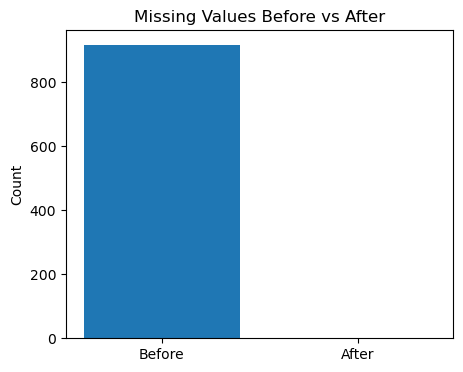

In [92]:
import matplotlib.pyplot as plt
missing_before = df.isnull().sum().sum()
missing_after = cleaned_df.isnull().sum().sum()

plt.figure(figsize=(5,4))
plt.bar(
    ["Before", "After"],
    [missing_before, missing_after]
)

plt.title("Missing Values Before vs After")
plt.ylabel("Count")
plt.show()

In [14]:
def recommend_duplicates(df):

    duplicate_count = df.duplicated().sum()

    if duplicate_count == 0:
        return {
            "Recommendation": "No Action Needed",
            "Reason": "No duplicate rows found."
        }

    return {
        "Recommendation": "Remove Duplicates",
        "Reason": f"{duplicate_count} duplicate rows detected."
    }

In [15]:
duplicate_recommendation = recommend_duplicates(df)

print("Recommendation:",
      duplicate_recommendation["Recommendation"])

print("Reason:",
      duplicate_recommendation["Reason"])

Recommendation: Remove Duplicates
Reason: 119 duplicate rows detected.


In [16]:
def remove_duplicates(df):
    return df.drop_duplicates()

In [17]:
df_clean = df.copy()

print("Before:",
      df_clean.duplicated().sum())

df_clean = remove_duplicates(df_clean)

print("After:",
      df_clean.duplicated().sum())

print("New Shape:",
      df_clean.shape)

Before: 119
After: 0
New Shape: (782, 15)


In [18]:
def recommend_outliers(df, col):

    outlier_count = detect_outliers_iqr(df, col)

    if outlier_count == 0:
        return {
            "Recommendation": "No Treatment Needed",
            "Reason": "No outliers detected."
        }

    skew = abs(df[col].dropna().skew())

    if skew < 0.5:
        recommendation = "Z-Score Method"

        reason = (
            f"{outlier_count} outliers detected. "
            f"Skewness = {skew:.2f}. "
            "Data is approximately normal."
        )

    else:
        recommendation = "IQR Method"

        reason = (
            f"{outlier_count} outliers detected. "
            f"Skewness = {skew:.2f}. "
            "Data is skewed."
        )

    return {
        "Recommendation": recommendation,
        "Alternatives": [
            "IQR Method",
            "Z-Score Method",
            "Isolation Forest"
        ],
        "Reason": reason
    }

In [19]:
def detect_outliers_iqr(df, col):

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((df[col] < lower) |
                (df[col] > upper)).sum()

    return outliers

In [20]:
for col in ["age", "fare"]:

    rec = recommend_outliers(df, col)

    print("\n" + "=" * 50)

    print("Column:", col)

    print("Recommendation:",
          rec["Recommendation"])

    print("Reason:",
          rec["Reason"])

    if "Alternatives" in rec:

        print("\nAlternatives:")

        for alt in rec["Alternatives"]:
            print("-", alt)


Column: age
Recommendation: Z-Score Method
Reason: 9 outliers detected. Skewness = 0.36. Data is approximately normal.

Alternatives:
- IQR Method
- Z-Score Method
- Isolation Forest

Column: fare
Recommendation: IQR Method
Reason: 119 outliers detected. Skewness = 17.88. Data is skewed.

Alternatives:
- IQR Method
- Z-Score Method
- Isolation Forest


In [21]:
from scipy.stats import zscore

def remove_outliers_iqr(df, col):

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    return df[
        (df[col] >= lower) &
        (df[col] <= upper)
    ]


def remove_outliers_zscore(df, col, threshold=3):

    temp = df.copy()

    temp = temp[temp[col].notnull()]

    z_scores = zscore(temp[col])

    return temp[abs(z_scores) < threshold]

In [22]:
df_outlier = df.copy()

rec = recommend_outliers(df_outlier, "fare")

method = rec["Recommendation"]

if method == "IQR Method":
    df_outlier = remove_outliers_iqr(df_outlier, "fare")

elif method == "Z-Score Method":
    df_outlier = remove_outliers_zscore(df_outlier, "fare")

print("Method Used:", method)

Method Used: IQR Method


In [23]:
# Testing 
print("Shape before:", df.shape)

print("Fare outliers before:",
      detect_outliers_iqr(df, "fare"))

Shape before: (901, 15)
Fare outliers before: 119


In [24]:
print("\nShape after:", df_outlier.shape)

print("Fare outliers after:",
      detect_outliers_iqr(df_outlier, "fare"))


Shape after: (782, 15)
Fare outliers after: 25


In [25]:
df_age = df.copy()

rec = recommend_outliers(df_age, "age")

method = rec["Recommendation"]

if method == "IQR Method":
    df_age = remove_outliers_iqr(df_age, "age")

elif method == "Z-Score Method":
    df_age = remove_outliers_zscore(df_age, "age")

print("Method Used:", method)

print("Age outliers after:",
      detect_outliers_iqr(df_age, "age"))

Method Used: Z-Score Method
Age outliers after: 12


In [26]:
def recommend_encoding(df):

    recommendations = {}

    categorical_cols = df.select_dtypes(
        include=["object", "category", "bool"]
    ).columns

    for col in categorical_cols:

        unique_values = df[col].nunique()

        if unique_values == 2:

            recommendations[col] = {
                "Recommendation": "Label Encoding",
                "Alternatives": [
                    "One-Hot Encoding"
                ],
                "Reason": (
                    f"{unique_values} unique values detected. "
                    "Binary categorical feature."
                )
            }

        elif unique_values <= 10:

            recommendations[col] = {
                "Recommendation": "One-Hot Encoding",
                "Alternatives": [],
                "Reason": (
                    f"{unique_values} unique values detected. "
                    "Low-cardinality categorical feature."
                )
            }

        else:

            recommendations[col] = {
                "Recommendation": "Frequency Encoding",
                "Alternatives": [],
                "Reason": (
                    f"{unique_values} unique values detected. "
                    "High-cardinality categorical feature."
                )
            }

    return recommendations

In [27]:
encoding_rec = recommend_encoding(df)

for col, rec in encoding_rec.items():

    print("\n" + "=" * 50)

    print("Column:", col)

    print("Recommendation:",
          rec["Recommendation"])

    print("Reason:",
          rec["Reason"])

    print("\nAlternatives:")

    for alt in rec["Alternatives"]:
        print("-", alt)


Column: sex
Recommendation: Label Encoding
Reason: 2 unique values detected. Binary categorical feature.

Alternatives:
- One-Hot Encoding

Column: embarked
Recommendation: One-Hot Encoding
Reason: 3 unique values detected. Low-cardinality categorical feature.

Alternatives:

Column: class
Recommendation: One-Hot Encoding
Reason: 3 unique values detected. Low-cardinality categorical feature.

Alternatives:

Column: who
Recommendation: One-Hot Encoding
Reason: 3 unique values detected. Low-cardinality categorical feature.

Alternatives:

Column: adult_male
Recommendation: Label Encoding
Reason: 2 unique values detected. Binary categorical feature.

Alternatives:
- One-Hot Encoding

Column: deck
Recommendation: One-Hot Encoding
Reason: 7 unique values detected. Low-cardinality categorical feature.

Alternatives:

Column: embark_town
Recommendation: One-Hot Encoding
Reason: 3 unique values detected. Low-cardinality categorical feature.

Alternatives:

Column: alive
Recommendation: Label 

In [77]:
from sklearn.preprocessing import LabelEncoder
def one_hot_encode(df, col):

    return pd.get_dummies(
        df,
        columns=[col],
        drop_first=True
    )

def label_encode(df, col):

    df_copy = df.copy()

    le = LabelEncoder()

    df_copy[col] = le.fit_transform(
        df_copy[col].astype(str)
    )

    return df_copy

def frequency_encode(df, col):

    df_copy = df.copy()

    freq = df_copy[col].value_counts()

    df_copy[col] = df_copy[col].map(freq)

    return df_copy
    

In [78]:
df_encoded = df.copy()

rec = recommend_encoding(df_encoded)

method = rec["sex"]["Recommendation"]

print("Method Used:", method)

Method Used: Label Encoding


In [32]:
if method == "One-Hot Encoding":

    df_encoded = one_hot_encode(
        df_encoded,
        "sex"
    )

elif method == "Frequency Encoding":

    df_encoded = frequency_encode(
        df_encoded,
        "sex"
    )

elif method == "Label Encoding":

    df_encoded = label_encode(
        df_encoded,
        "sex"
    )

In [33]:
print("Before:")

print(df["sex"].head())

Before:
0      male
1    female
2    female
3    female
4      male
Name: sex, dtype: object


In [34]:
print("\nAfter:")

print(df_encoded.head())


After:
   survived  pclass  sex   age  sibsp  parch     fare embarked  class    who  \
0         0       3    1  22.0      1      0   7.2500        S  Third    man   
1         1       1    0  38.0      1      0  71.2833        C  First  woman   
2         1       3    0  26.0      0      0   7.9250        S  Third  woman   
3         1       1    0  35.0      1      0  53.1000        S  First  woman   
4         0       3    1  35.0      0      0   8.0500        S  Third    man   

   adult_male deck  embark_town alive  alone  
0        True  NaN  Southampton    no  False  
1       False    C    Cherbourg   yes  False  
2       False  NaN  Southampton   yes   True  
3       False    C  Southampton   yes  False  
4        True  NaN  Southampton    no   True  


In [35]:
def recommend_scaling(df):

    recommendations = {}

    numerical_cols = df.select_dtypes(
        include=["int64", "float64"]
    ).columns

    for col in numerical_cols:

        outliers = detect_outliers_iqr(df, col)
        skew = abs(df[col].dropna().skew())

        if outliers > 0:

            recommendation = "RobustScaler"

            reason = (
                f"{outliers} outliers detected. "
                "RobustScaler is less affected by outliers."
            )

        elif skew < 0.5:

            recommendation = "StandardScaler"

            reason = (
                f"Skewness = {skew:.2f}. "
                "Data is approximately normal."
            )

        else:

            recommendation = "MinMaxScaler"

            reason = (
                f"Skewness = {skew:.2f}. "
                "Data is not approximately normal."
            )

        recommendations[col] = {
            "Recommendation": recommendation,
            "Alternatives": [
                "StandardScaler",
                "MinMaxScaler",
                "RobustScaler"
            ],
            "Reason": reason
        }

    return recommendations

In [36]:
scaling_rec = recommend_scaling(df)

for col, rec in scaling_rec.items():

    print("\n" + "=" * 50)

    print("Column:", col)

    print("Recommendation:",
          rec["Recommendation"])

    print("Reason:",
          rec["Reason"])

    print("\nAlternatives:")

    for alt in rec["Alternatives"]:
        print("-", alt)


Column: survived
Recommendation: StandardScaler
Reason: Skewness = 0.46. Data is approximately normal.

Alternatives:
- StandardScaler
- MinMaxScaler
- RobustScaler

Column: pclass
Recommendation: MinMaxScaler
Reason: Skewness = 0.63. Data is not approximately normal.

Alternatives:
- StandardScaler
- MinMaxScaler
- RobustScaler

Column: age
Recommendation: RobustScaler
Reason: 9 outliers detected. RobustScaler is less affected by outliers.

Alternatives:
- StandardScaler
- MinMaxScaler
- RobustScaler

Column: sibsp
Recommendation: RobustScaler
Reason: 46 outliers detected. RobustScaler is less affected by outliers.

Alternatives:
- StandardScaler
- MinMaxScaler
- RobustScaler

Column: parch
Recommendation: RobustScaler
Reason: 216 outliers detected. RobustScaler is less affected by outliers.

Alternatives:
- StandardScaler
- MinMaxScaler
- RobustScaler

Column: fare
Recommendation: RobustScaler
Reason: 119 outliers detected. RobustScaler is less affected by outliers.

Alternatives:
-

In [37]:
from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    RobustScaler
)

In [38]:
def standard_scale(df, col):

    df_copy = df.copy()

    scaler = StandardScaler()

    df_copy[[col]] = scaler.fit_transform(
        df_copy[[col]]
    )

    return df_copy

In [39]:
def minmax_scale(df, col):

    df_copy = df.copy()

    scaler = MinMaxScaler()

    df_copy[[col]] = scaler.fit_transform(
        df_copy[[col]]
    )

    return df_copy
    

In [40]:
def robust_scale(df, col):

    df_copy = df.copy()

    scaler = RobustScaler()

    df_copy[[col]] = scaler.fit_transform(
        df_copy[[col]]
    )

    return df_copy

In [41]:
print("Before Scaling:")

print(df["fare"].describe())

Before Scaling:
count     901.000000
mean       37.481260
std       121.889336
min         0.000000
25%         7.925000
50%        14.454200
75%        31.275000
max      2930.416000
Name: fare, dtype: float64


In [42]:
df_scaled = df.copy()

rec = recommend_scaling(df_scaled)

method = rec["fare"]["Recommendation"]

print("Method Used:", method)

Method Used: RobustScaler


In [43]:
if method == "StandardScaler":

    df_scaled = standard_scale(
        df_scaled,
        "fare"
    )

elif method == "MinMaxScaler":

    df_scaled = minmax_scale(
        df_scaled,
        "fare"
    )

elif method == "RobustScaler":

    df_scaled = robust_scale(
        df_scaled,
        "fare"
    )

In [44]:
print("\nAfter Scaling:")

print(df_scaled["fare"].describe())


After Scaling:
count    901.000000
mean       0.986170
std        5.220100
min       -0.619024
25%       -0.279623
50%        0.000000
75%        0.720377
max      124.880591
Name: fare, dtype: float64


# Preprocessing final function

In [104]:
def preprocess_dataset(df):

    df_processed = df.copy()

    report = {}

    # Missing Values
    missing_rec = recommend_missing_values(df_processed)

    for col, rec in missing_rec.items():

        method = rec["Recommendation"]

        if method == "Mean Imputation":
            df_processed = mean_imputation(df_processed, col)

        elif method == "Median Imputation":
            df_processed = median_imputation(df_processed, col)

        elif method == "Mode Imputation":
            df_processed = mode_imputation(df_processed, col)

        elif method == "Drop Column":
            df_processed = df_processed.drop(columns=[col])

        report[col] = method

     # Duplicates
    duplicates_removed = df_processed.duplicated().sum()

    df_processed = df_processed.drop_duplicates()

    report["Duplicates Removed"] = int(duplicates_removed)


       # Outliers
    outlier_report = {}

    # Automatically detect continuous numerical columns
    outlier_cols = []

    numerical_cols = df_processed.select_dtypes(
        include=["int64", "float64"]
    ).columns

    for col in numerical_cols:

        # Skip binary/discrete columns
        if df_processed[col].nunique() > 10:

            outlier_cols.append(col)

    # Apply outlier treatment
    for col in outlier_cols:

        rec = recommend_outliers(
            df_processed,
            col
        )

        method = rec["Recommendation"]

        if method == "IQR Method":

            df_processed = remove_outliers_iqr(
                df_processed,
                col
            )

        elif method == "Z-Score Method":

            df_processed = remove_outliers_zscore(
                df_processed,
                col
            )

        outlier_report[col] = method

    report["Outliers"] = outlier_report

        # Encoding
    encoding_rec = recommend_encoding(df_processed)

    encoding_report = {}

    for col, rec in encoding_rec.items():

        method = rec["Recommendation"]

        if method == "Label Encoding":
            df_processed = label_encode(df_processed, col)

        elif method == "One-Hot Encoding":
            df_processed = one_hot_encode(df_processed, col)

        elif method == "Frequency Encoding":
            df_processed = frequency_encode(df_processed, col)

        encoding_report[col] = method

    report["Encoding"] = encoding_report

    # Scaling
    scaling_rec = recommend_scaling(df_processed)

    scaling_report = {}

    numerical_cols = df_processed.select_dtypes(
        include=["int64", "float64"]
    ).columns

    for col in numerical_cols:

        rec = scaling_rec[col]

        method = rec["Recommendation"]

        if method == "StandardScaler":
            df_processed = standard_scale(df_processed, col)

        elif method == "MinMaxScaler":
            df_processed = minmax_scale(df_processed, col)

        elif method == "RobustScaler":
            df_processed = robust_scale(df_processed, col)

        scaling_report[col] = method

    report["Scaling"] = scaling_report

    return df_processed, report

In [105]:
cleaned_df, report = preprocess_dataset(df)

In [106]:
print(cleaned_df.isnull().sum())

survived                   0
pclass                     0
sex                        0
age                        0
sibsp                      0
parch                      0
fare                       0
adult_male                 0
alive                      0
alone                      0
embarked_Q                 0
embarked_S                 0
class_Second               0
class_Third                0
who_man                    0
who_woman                  0
embark_town_Queenstown     0
embark_town_Southampton    0
dtype: int64


In [107]:
print(report)

{'age': 'Mean Imputation', 'embarked': 'Mode Imputation', 'deck': 'Drop Column', 'embark_town': 'Mode Imputation', 'Duplicates Removed': 129, 'Outliers': {'age': 'Z-Score Method', 'fare': 'IQR Method'}, 'Encoding': {'sex': 'Label Encoding', 'embarked': 'One-Hot Encoding', 'class': 'One-Hot Encoding', 'who': 'One-Hot Encoding', 'adult_male': 'Label Encoding', 'embark_town': 'One-Hot Encoding', 'alive': 'Label Encoding', 'alone': 'Label Encoding'}, 'Scaling': {'survived': 'MinMaxScaler', 'pclass': 'MinMaxScaler', 'sex': 'MinMaxScaler', 'age': 'RobustScaler', 'sibsp': 'RobustScaler', 'parch': 'RobustScaler', 'fare': 'RobustScaler', 'adult_male': 'StandardScaler', 'alive': 'MinMaxScaler', 'alone': 'StandardScaler'}}


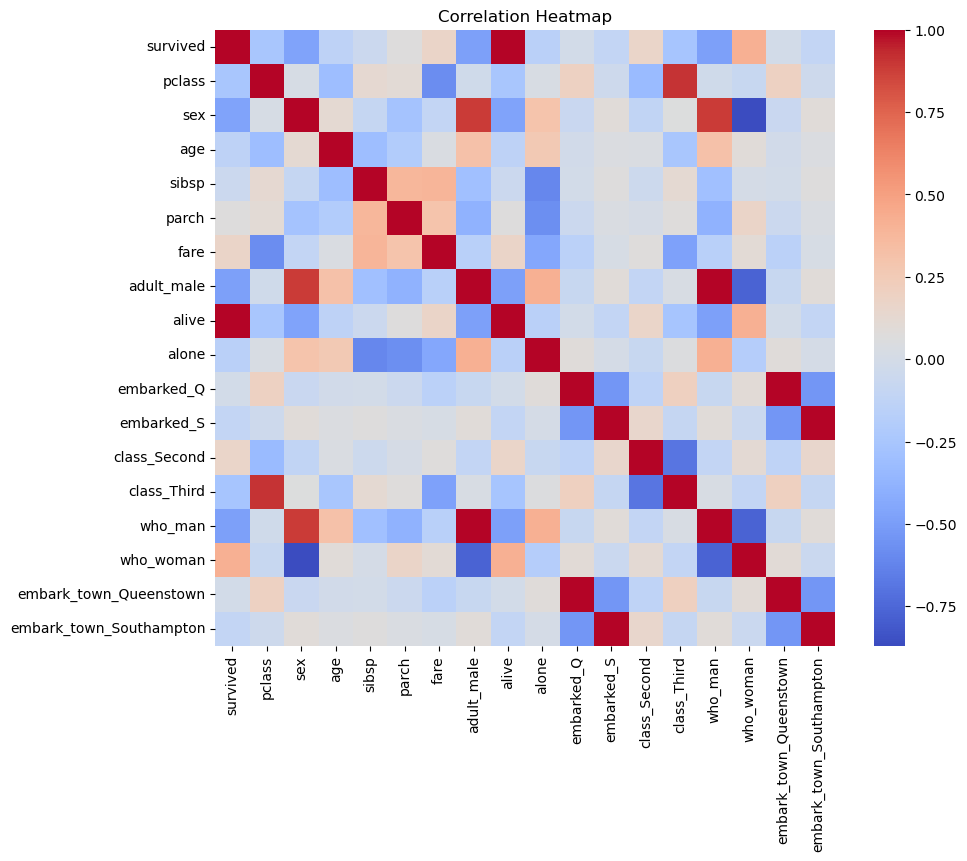

In [108]:
import seaborn as sns

plt.figure(figsize=(10,8))

sns.heatmap(
    cleaned_df.corr(numeric_only=True),
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

In [109]:
cleaned_df, report = preprocess_dataset(df)

print(cleaned_df.shape)

print(report["Outliers"])

(668, 18)
{'age': 'Z-Score Method', 'fare': 'IQR Method'}


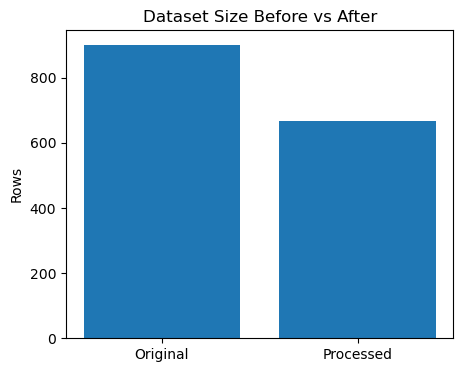

In [110]:
import matplotlib.pyplot as plt

original_rows = df.shape[0]
processed_rows = cleaned_df.shape[0]

plt.figure(figsize=(5,4))
plt.bar(
    ["Original", "Processed"],
    [original_rows, processed_rows]
)

plt.title("Dataset Size Before vs After")
plt.ylabel("Rows")
plt.show()

In [111]:
cleaned_df.to_csv(
    "cleaned_dataset.csv",
    index=False
)

In [112]:
import json

with open("report.json", "w") as f:
    json.dump(report, f, indent=4, default=str)

# Testing another data sets

In [113]:
import seaborn as sns

penguins = sns.load_dataset("penguins")

cleaned_penguins, penguin_report = preprocess_dataset(penguins)

print(cleaned_penguins.shape)
print(penguin_report)

(344, 9)
{'bill_length_mm': 'Mean Imputation', 'bill_depth_mm': 'Mean Imputation', 'flipper_length_mm': 'Mean Imputation', 'body_mass_g': 'Mean Imputation', 'sex': 'Mode Imputation', 'Duplicates Removed': 0, 'Outliers': {'bill_length_mm': 'No Treatment Needed', 'bill_depth_mm': 'No Treatment Needed', 'flipper_length_mm': 'No Treatment Needed', 'body_mass_g': 'No Treatment Needed'}, 'Encoding': {'species': 'One-Hot Encoding', 'island': 'One-Hot Encoding', 'sex': 'Label Encoding'}, 'Scaling': {'bill_length_mm': 'StandardScaler', 'bill_depth_mm': 'StandardScaler', 'flipper_length_mm': 'StandardScaler', 'body_mass_g': 'StandardScaler', 'sex': 'StandardScaler'}}
